# Classification Metrics

Classification metrics are used to evaluate the performance of classification models.

In classification, the model predicts discrete classes such as:

- Spam / Not Spam
- Disease / No Disease
- Cat / Dog
- Pass / Fail
- Setosa / Versicolor / Virginica

Different metrics measure different aspects of model performance.

### Main Classification Metrics

1. Confusion Matrix
2. Accuracy
3. Precision
4. Recall
5. F1-Score
6. Specificity
7. ROC-AUC
8. Log Loss
9. Classification Report

The appropriate metric depends on the problem and the importance of different types of errors.

In [10]:
import numpy as np

import numpy as np

y_test = np.array([
    0, 0, 0, 0, 1,
    1, 1, 1, 0, 1,
    0, 1, 0, 1, 1
])

y_pred = np.array([
    0, 0, 1, 0, 1,
    1, 0, 1, 0, 1,
    0, 1, 0, 0, 1
])

print("y_test:")
print(y_test)

print("\ny_pred:")
print(y_pred)

y_test:
[0 0 0 0 1 1 1 1 0 1 0 1 0 1 1]

y_pred:
[0 0 1 0 1 1 0 1 0 1 0 1 0 0 1]


In [11]:
import pandas as pd

comparison = pd.DataFrame({
    "y_test": y_test,
    "y_pred": y_pred
})

comparison

,y_test,y_pred
0,0,0
1,0,0
2,0,1
3,0,0
4,1,1
5,1,1
6,1,0
7,1,1
8,0,0
9,1,1


# Confusion Matrix

A confusion matrix summarizes the predictions made by a classification model.

For binary classification, there are four possible outcomes:

| Actual | Predicted | Result |
|---|---|---|
| Positive | Positive | True Positive (TP) |
| Negative | Negative | True Negative (TN) |
| Negative | Positive | False Positive (FP) |
| Positive | Negative | False Negative (FN) |

### True Positive (TP)

The model correctly predicts the positive class.

### True Negative (TN)

The model correctly predicts the negative class.

### False Positive (FP)

The model predicts positive, but the actual class is negative.

### False Negative (FN)

The model predicts negative, but the actual class is positive.

### Confusion Matrix Structure

              Predicted
              Positive  Negative

Actual Positive    TP       FN
Actual Negative    FP       TN

In [12]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[6 1]
 [2 6]]


## Visualizing the Confusion Matrix

A heatmap makes the confusion matrix easier to understand.

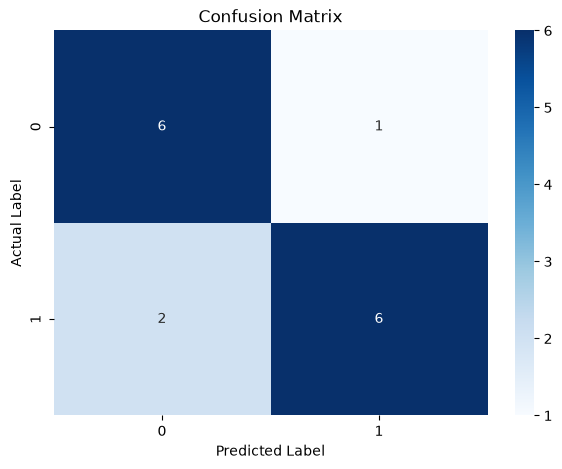

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

# Accuracy

Accuracy measures the percentage of total predictions that were correct.

$$
Accuracy =
\frac{TP + TN}
{TP + TN + FP + FN}
$$

### Interpretation

If:

```text
Accuracy = 0.95

In [14]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

Accuracy: 0.8
Accuracy (%): 80.0


# Precision

Precision measures how many of the observations predicted as positive were actually positive.

$$
Precision =
\frac{TP}
{TP + FP}
$$

### Example

Suppose the model predicts:

```text
100 emails as Spam

In [15]:
from sklearn.metrics import precision_score

precision = precision_score(
    y_test,
    y_pred,
    average="weighted"
)

print("Precision:", precision)

Precision: 0.8071428571428572


# Recall

Recall measures how many of the actual positive observations were correctly identified by the model.

Recall is also called:

- Sensitivity
- True Positive Rate (TPR)

$$
Recall =
\frac{TP}
{TP + FN}
$$

### Example

Suppose there are:

```text
100 actual positive cases

In [16]:
from sklearn.metrics import recall_score

recall = recall_score(
    y_test,
    y_pred,
    average="weighted"
)

print("Recall:", recall)

Recall: 0.8


# F1-Score

F1-Score is the harmonic mean of Precision and Recall.

$$
F1 =
2 \times
\frac{Precision \times Recall}
{Precision + Recall}
$$

F1-Score provides a balance between precision and recall.

### Why Use F1-Score?

F1-Score is particularly useful when:

- Classes are imbalanced
- Both False Positives and False Negatives matter
- You need a balance between Precision and Recall

### Range

$$
0 \leq F1 \leq 1
$$

Higher F1-Score generally indicates better performance.

In [17]:
from sklearn.metrics import f1_score

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted"
)

print("F1-Score:", f1)

F1-Score: 0.8


# Specificity

Specificity measures how well the model identifies actual negative observations.

It is also called the:

**True Negative Rate (TNR)**

$$
Specificity =
\frac{TN}
{TN + FP}
$$

### Interpretation

High specificity means the model produces fewer False Positives.

Specificity is particularly important when correctly identifying negative cases is important.

In [18]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

tn, fp, fn, tp = cm.ravel()

specificity = tn / (tn + fp)

print("Specificity:", specificity)

Specificity: 0.8571428571428571


# Classification Report

The Classification Report provides several important metrics together:

- Precision
- Recall
- F1-Score
- Support

### Support

Support represents the number of actual observations belonging to each class.

The classification report is useful for quickly evaluating each individual class.

In [19]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.75      0.86      0.80         7
           1       0.86      0.75      0.80         8

    accuracy                           0.80        15
   macro avg       0.80      0.80      0.80        15
weighted avg       0.81      0.80      0.80        15

